# Iterative Temporal Parent Discovery

Dev | Jacqueline Maasch | September 2026

In [1]:
# General imports.
import pandas as pd
import numpy as np
#import pickle
import matplotlib.pyplot as plt
import time
from string import ascii_uppercase as alphabet
import scipy.stats as st

# Time series causal discovery.
import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI # also for PCMCI+
from tigramite.independence_tests.gsquared import Gsquared # univariate discrete/categorical vars
from tigramite.independence_tests.cmisymb import CMIsymb # multivariate discrete/categorical vars (permutation-based)
from tigramite.independence_tests.parcorr import ParCorr # univariate, continuous variables with linear dependencies and Gaussian noise

# VLCD.
from vlcd import PCMCIConfig, pcmci

# Vanilla causal discovery.
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.cit import CIT

# Custom discovery algorithms.
from padl_itpd import PaDL
from itpd import ITPD, Utils
# Naive implementation.
from padl_naive import PaDL
from itpd_naive import ITPDNaive

# Metrics.
#from dodiscover.metrics import structure_hamming_dist as SHD
from cdt.metrics import precision_recall
from cdt.metrics import SHD
from cdt.metrics import SID

# Graphical modeling.
import networkx as nx

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


# ITPD

## Generate random time series

In [2]:
# Get random data.
u = Utils()
dfs = []
graphs = []
adj_matrices = []
p2c_list = []
c2p_list = []
M = 1_0
T = 10
N = 10
max_children = 2
plot = False
iters = 10 # total random datasets to generate.

for i in range(iters):
    df, p2c, c2p, G, true_adj = u.get_data(M = M, 
                                           T = T,
                                           N = N, 
                                           max_children = max_children,
                                           plot = plot)
    dfs.append(df)
    graphs.append(G)
    adj_matrices.append(true_adj)
    p2c_list.append(p2c)
    c2p_list.append(c2p)

In [3]:
dfs[0]

,A_0,A_1,A_2,A_3,A_4,A_5,A_6,A_7,A_8,A_9,...,J_0,J_1,J_2,J_3,J_4,J_5,J_6,J_7,J_8,J_9
0,1.292087,-3.130099,-3.707422,4.456487,6.569704,-6.775512,11.481153,14.312784,13.898738,-11.827186,...,-0.398849,-0.681863,0.000955,0.704688,0.088217,-2.981578,1.938384,-2.507964,-11.221314,-34.736234
1,0.467218,-0.295685,2.455757,-4.250882,-7.819612,6.962041,-10.730188,-18.465743,-16.237325,12.756263,...,-1.091398,-0.394955,-2.568010,2.185408,-0.929034,5.577955,1.310411,-2.656635,-0.445372,10.641481
2,0.254600,-0.771003,-0.488545,1.166208,1.882748,0.730007,-2.967423,-3.688113,1.465703,0.966505,...,-0.186723,-0.965081,3.468128,-1.378795,1.200035,0.531740,-12.432840,9.737346,-1.855704,-5.409677
3,0.232291,1.610189,5.159380,-4.678520,-5.941636,5.017543,-6.626043,-13.492108,-11.435888,9.427092,...,0.601383,0.910684,2.065969,0.919080,-0.313192,4.003105,-3.792296,1.291218,21.259412,52.626700
4,-1.120911,0.283924,1.205226,-1.232271,-1.393353,0.317301,-0.697249,2.093836,4.475005,-2.611685,...,1.730287,2.244093,-0.476471,-0.688217,0.375363,0.354047,6.905994,-5.150140,-19.084024,-36.721688
5,1.573991,-3.424585,-1.621675,-0.359090,-0.086589,2.250041,-4.734024,-7.265253,-6.424937,5.983225,...,-0.507506,-0.713970,-1.128508,1.811222,-1.053987,-13.537249,27.276626,-20.339955,-30.203078,-71.621978
6,-0.726894,2.174767,0.223286,0.887349,2.130664,-0.938014,1.992621,2.546584,0.431776,0.401420,...,-2.015775,-2.534141,1.829471,0.102056,0.526465,-6.524835,20.319097,-16.892097,-47.906259,-94.772184
7,-0.264752,-2.206676,-0.382430,1.018211,2.347300,-0.578953,0.984873,-0.421981,1.264429,-0.786077,...,-1.173227,-0.208355,0.413628,1.276816,-1.436620,-2.910558,9.253847,-8.016594,-1.382493,-10.852358
8,1.013406,-1.934552,-2.424454,3.350759,5.031305,-5.600483,8.164461,11.923448,14.783000,-8.677109,...,1.979288,3.218435,-0.647170,0.144816,-0.197129,3.766411,-4.342142,2.732587,18.289745,34.546980
9,0.425957,0.011827,-0.769139,1.890822,2.921612,0.899727,-2.372192,-1.938688,-1.955850,1.212264,...,-0.776615,-0.167676,-0.532534,0.279819,0.477822,1.157573,-12.420752,8.725094,8.145517,16.259593


In [4]:
p2c_list[0]

{'A_0': ['A_1'],
 'A_1': ['A_2', 'B_8'],
 'A_2': ['A_3'],
 'A_3': ['A_4', 'F_9', 'F_4'],
 'A_4': ['A_5', 'C_8', 'G_8'],
 'A_5': ['A_6'],
 'A_6': ['A_7', 'F_7', 'D_7'],
 'A_7': ['A_8', 'I_9', 'F_8'],
 'A_8': ['A_9', 'F_9'],
 'A_9': [],
 'B_0': ['B_1'],
 'B_1': ['B_2'],
 'B_2': ['B_3', 'A_6', 'F_8'],
 'B_3': ['B_4', 'J_9'],
 'B_4': ['B_5'],
 'B_5': ['B_6'],
 'B_6': ['B_7', 'A_8', 'D_9'],
 'B_7': ['B_8', 'H_9', 'E_8'],
 'B_8': ['B_9', 'H_9'],
 'B_9': [],
 'C_0': ['C_1', 'J_2'],
 'C_1': ['C_2', 'G_5', 'A_2'],
 'C_2': ['C_3'],
 'C_3': ['C_4'],
 'C_4': ['C_5', 'A_5', 'D_6'],
 'C_5': ['C_6'],
 'C_6': ['C_7', 'A_8', 'J_8'],
 'C_7': ['C_8'],
 'C_8': ['C_9', 'J_9'],
 'C_9': [],
 'D_0': ['D_1', 'C_3'],
 'D_1': ['D_2'],
 'D_2': ['D_3', 'E_7'],
 'D_3': ['D_4', 'H_8', 'D_9'],
 'D_4': ['D_5'],
 'D_5': ['D_6'],
 'D_6': ['D_7', 'H_7', 'B_7'],
 'D_7': ['D_8'],
 'D_8': ['D_9', 'F_9', 'E_9'],
 'D_9': [],
 'E_0': ['E_1'],
 'E_1': ['E_2', 'J_8'],
 'E_2': ['E_3', 'I_9'],
 'E_3': ['E_4', 'J_6', 'I_7'],
 'E_4'

## Oracle

### ITPD

In [5]:
test = "oracle"
alpha = 0.01
tau_max = None
pairs = None
var_names = list(alphabet[:N])
ci_to_float = lambda x : (round(float(x[0]),3), round(float(x[1]),3))

auprs = []
shds = []
total_tests = []
cond_sizes = []
itpd_oracle_times = []

for i in range(iters):
    start = time.time()
    it = ITPD(dfs[i],
              var_names = var_names,
              pairs = pairs,
              independence_test = test,
              alpha = alpha,
              tau_max = tau_max,
              true_adj = adj_matrices[i])
    aupr, shd = it.itpd()
    itpd_oracle_times.append(time.time() - start)
    
    total_tests.append(np.sum(it.total_tests))
    cond_sizes_flat = [item for sublist in it.conditioning_set_sizes for item in sublist]
    cond_sizes += cond_sizes_flat
    
    auprs.append(aupr)
    shds.append(shd)


# Get 95% confidence intervals.
# Assuming t distribution.
time_ci = st.t.interval(0.95, 
                        len(itpd_oracle_times)-1, 
                        loc = np.mean(itpd_oracle_times), 
                        scale = st.sem(itpd_oracle_times))
tests_ci = st.t.interval(0.95, 
                        len(total_tests)-1, 
                        loc = np.mean(total_tests), 
                        scale = st.sem(total_tests))
cond_ci = st.t.interval(0.95, 
                        len(cond_sizes)-1, 
                        loc = np.mean(cond_sizes), 
                        scale = st.sem(cond_sizes))
auprs_ci = st.t.interval(0.95, 
                        len(auprs)-1, 
                        loc = np.mean(auprs), 
                        scale = st.sem(auprs))
shds_ci = st.t.interval(0.95, 
                        len(shds)-1, 
                        loc = np.mean(shds), 
                        scale = st.sem(shds))

print()
print(f"Mean runtime     : {round(np.mean(itpd_oracle_times),4)}s {ci_to_float(time_ci)}")
print(f"Mean total tests : {round(np.mean(total_tests),2)} {ci_to_float(tests_ci)}")
print(f"Mean cond. set   : {round(np.mean(cond_sizes),2)} {ci_to_float(cond_ci)}")
print()
print(f"Mean AUPR        : {round(np.mean(auprs)*100,2)} {ci_to_float(auprs_ci)}")
print(f"Mean SHD         : {round(np.mean(shds),2)} {ci_to_float(shds_ci)}")

ITPD complete in 2.2491 seconds.
ITPD complete in 2.4155 seconds.
ITPD complete in 2.2641 seconds.
ITPD complete in 2.1498 seconds.
ITPD complete in 2.0671 seconds.
ITPD complete in 2.2611 seconds.
ITPD complete in 2.2704 seconds.
ITPD complete in 2.0832 seconds.
ITPD complete in 2.3048 seconds.
ITPD complete in 2.14 seconds.

Mean runtime     : 2.2217s (2.144, 2.299)
Mean total tests : 14124.4 (13831.383, 14417.417)
Mean cond. set   : 63.19 (62.821, 63.566)

Mean AUPR        : 100.0 (nan, nan)
Mean SHD         : 0.0 (nan, nan)


invalid value encountered in multiply
invalid value encountered in multiply


### ITPD naive

In [6]:
naive_auprs = []
naive_shds = []
naive_total_tests = []
naive_cond_sizes = []
naive_itpd_oracle_times = []

for i in range(iters):
    start = time.time()
    it = ITPDNaive(dfs[i],
                  var_names = var_names,
                  pairs = pairs,
                  independence_test = test,
                  alpha = alpha,
                  tau_max = tau_max,
                  true_adj = adj_matrices[i])
    aupr, shd = it.itpd_naive()
    naive_itpd_oracle_times.append(time.time() - start)
    
    naive_total_tests.append(np.sum(it.total_tests))
    naive_cond_sizes_flat = [item for sublist in it.conditioning_set_sizes for item in sublist]
    naive_cond_sizes += naive_cond_sizes_flat
    
    naive_auprs.append(aupr)
    naive_shds.append(shd)

# Get 95% confidence intervals.
# Assuming t distribution.
naive_time_ci = st.t.interval(0.95, 
                        len(naive_itpd_oracle_times)-1, 
                        loc = np.mean(naive_itpd_oracle_times), 
                        scale = st.sem(naive_itpd_oracle_times))
naive_tests_ci = st.t.interval(0.95, 
                        len(naive_total_tests)-1, 
                        loc = np.mean(naive_total_tests), 
                        scale = st.sem(naive_total_tests))
naive_cond_ci = st.t.interval(0.95, 
                        len(naive_cond_sizes)-1, 
                        loc = np.mean(naive_cond_sizes), 
                        scale = st.sem(naive_cond_sizes))
naive_auprs_ci = st.t.interval(0.95, 
                        len(naive_auprs)-1, 
                        loc = np.mean(naive_auprs), 
                        scale = st.sem(naive_auprs))
naive_shds_ci = st.t.interval(0.95, 
                        len(naive_shds)-1, 
                        loc = np.mean(naive_shds), 
                        scale = st.sem(naive_shds))

print()
print(f"Mean runtime     : {round(np.mean(naive_itpd_oracle_times),4)}s {ci_to_float(naive_time_ci)}")
print(f"Mean total tests : {round(np.mean(naive_total_tests),2)} {ci_to_float(naive_tests_ci)}")
print(f"Mean cond. set   : {round(np.mean(naive_cond_sizes),2)} {ci_to_float(naive_cond_ci)}")
print()
print(f"Mean AUPR        : {round(np.mean(naive_auprs)*100,2)} {ci_to_float(naive_auprs_ci)}")
print(f"Mean SHD         : {round(np.mean(naive_shds),2)} {ci_to_float(naive_shds_ci)}")

ITPD complete in 2.5154 seconds.
ITPD complete in 2.7389 seconds.
ITPD complete in 2.5649 seconds.
ITPD complete in 2.4013 seconds.
ITPD complete in 2.3463 seconds.
ITPD complete in 2.5758 seconds.
ITPD complete in 2.5494 seconds.
ITPD complete in 2.3451 seconds.
ITPD complete in 2.6715 seconds.
ITPD complete in 2.4814 seconds.

Mean runtime     : 2.52s (2.427, 2.613)
Mean total tests : 15916.9 (15519.413, 16314.387)
Mean cond. set   : 63.19 (62.821, 63.566)

Mean AUPR        : 100.0 (nan, nan)
Mean SHD         : 0.0 (nan, nan)


invalid value encountered in multiply
invalid value encountered in multiply


In [7]:
np.mean(itpd_oracle_times) / np.mean(naive_itpd_oracle_times)

np.float64(0.8816092016878897)

In [8]:
np.mean(total_tests) / np.mean(naive_total_tests)

np.float64(0.8873838498702636)

In [9]:
np.mean(cond_sizes) / np.mean(naive_cond_sizes)

np.float64(1.0)

In [10]:
# Lower variance?
tests_var = [np.var(total_tests), np.var(naive_total_tests)]
tests_var

[np.float64(151001.84000000003), np.float64(277871.29000000004)]

In [11]:
# Lower variance?
times_var = [np.var(itpd_oracle_times), np.var(naive_itpd_oracle_times)]
times_var

[np.float64(0.010592129539571147), np.float64(0.01533188449025374)]

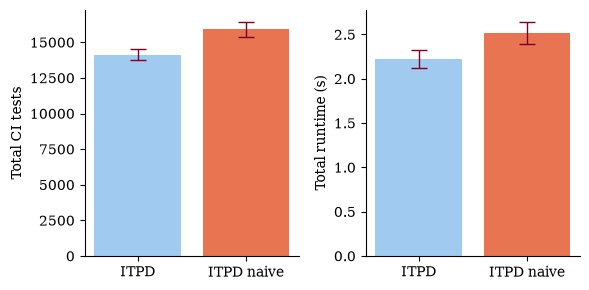

In [12]:
plt.rcParams["font.family"] = "serif"

categories = ["ITPD", "ITPD naive"]
bar_colors = ["#A1CAF1", "#E97451"]

times_means = [np.mean(itpd_oracle_times), np.mean(naive_itpd_oracle_times)]
times_stdevs = [np.std(itpd_oracle_times), np.std(naive_itpd_oracle_times)]

tests_means = [np.mean(total_tests), np.mean(naive_total_tests)]
tests_stdevs = [np.std(total_tests), np.std(naive_total_tests)]

fig, axs = plt.subplots(1, 2, figsize = (6, 3))

axs[0].bar(
    categories, 
    tests_means, 
    yerr = tests_stdevs, 
    capsize = 6,
    color = bar_colors, 
    error_kw = dict(ecolor = "#800020", lw = 1, capthick = 1)
)
axs[0].spines["top"].set_visible(False)
axs[0].spines["right"].set_visible(False)

axs[0].set_ylabel("Total CI tests")

axs[1].bar(
    categories, 
    times_means, 
    yerr = times_stdevs, 
    capsize = 6,
    color = bar_colors, 
    error_kw = dict(ecolor = "#800020", lw = 1, capthick = 1)
)
axs[1].spines["top"].set_visible(False)
axs[1].spines["right"].set_visible(False)

axs[1].set_ylabel("Total runtime (s)")

plt.tight_layout()
plt.show()

# End of document